# 02. Loading Engineering Datasets
**Engineering Data Processing with Python** | one-day course | about 35 minutes

> **TRAINER / SOLUTION VERSION.** Every blank is filled in and the notebook has been run.


In [1]:
# @title Setup: run this cell first (it loads the course data)
# ===================== SETUP: run this cell first (click it, then Shift+Enter) =====================
# It makes sure the course data is available in this Colab session and loads the tools we need.
import os, zipfile, urllib.request
from pathlib import Path

DATA_ZIP_URL = "https://raw.githubusercontent.com/buildyourai/ei-python-data-processing/main/data.zip"   # course data (fictional / public)

def get_course_data():
    if Path("data").is_dir():
        print("Data folder found:", sorted(p.name for p in Path("data").iterdir())[:20])
        return
    if not Path("data.zip").exists() and DATA_ZIP_URL:
        print("Downloading course data...")
        urllib.request.urlretrieve(DATA_ZIP_URL, "data.zip")
    zip_path = Path("data.zip")
    if not zip_path.exists():
        try:
            from google.colab import files
            print("Choose data.zip from your computer (your trainer will tell you where it is).")
            uploaded = files.upload()
            zip_path = Path(next(iter(uploaded)))
        except ImportError:
            raise FileNotFoundError("Put data.zip or the data folder next to this notebook.")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(".")
    print("Data ready:", sorted(p.name for p in Path("data").iterdir()))

get_course_data()
Path("outputs").mkdir(exist_ok=True)

import pandas as pd
import numpy as np
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

def check(condition, ok="Looks right.", hint="Not quite yet. Re-read the instructions above the cell."):
    """Tiny self-check helper used throughout the course."""
    print(("PASS: " + ok) if condition else ("NOT YET: " + hint))

Data folder found: ['3dprinter.csv', 'asset_register.xlsx', 'boiler.json', 'capstone', 'checkpoints', 'concrete.csv', 'manifest.TXT', 'manifest.csv', 'sensor_readings.csv', 'steel.csv', 'thermal-profiles.xlsx', 'work_orders_cmms.csv', 'work_orders_legacy.xlsx']


## The point of this module

pandas will load almost anything without an error. **Loading without an error does not mean loading correctly.**
You will load a CSV and two Excel files, get the dates right, and find a fault that no error message will report.

## 1. A year of energy readings from a steel plant (35,000 rows)

In [2]:
steel = pd.read_csv("data/steel.csv")
print(steel.shape)
steel.head()

(35040, 11)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [3]:
steel.dtypes

date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               object
Day_of_week                              object
Load_Type                                object
dtype: object

`date` is `object` (text). To sort by time or total by day, it must become a real date.

### The day/month trap
Irish exports write day/month/year. Left to guess, pandas often assumes month/day. Watch the 1st of February:

In [4]:
print(pd.to_datetime("01/02/2018 00:15"))                            # guessed: 2 January. Wrong, no error.
print(pd.to_datetime("01/02/2018 00:15", format="%d/%m/%Y %H:%M"))   # told: 1 February. Right.

2018-01-02 00:15:00
2018-02-01 00:15:00


Always tell pandas the format. The codes: `%d` day, `%m` month, `%Y` year, `%H` hour, `%M` minute.

### Your turn 2.1
Convert the steel dates. The format is `%d/%m/%Y %H:%M`, exactly as in the example above.

In [5]:
steel["date"] = pd.to_datetime(steel["date"], format="%d/%m/%Y %H:%M")
print("From", steel["date"].min(), "to", steel["date"].max())

From 2018-01-01 00:00:00 to 2018-12-31 23:45:00


In [6]:
check(steel["date"].dt.month.nunique() == 12, "All 12 months present.", "Check the format: day first, then month.")

PASS: All 12 months present.


## 2. A fault nobody will tell you about

Readings should move forwards in time. Do they? Run and read.

In [7]:
print("Does time always go forwards?", steel["date"].is_monotonic_increasing)
steel.loc[94:97, ["date", "Usage_kWh", "NSM"]]

Does time always go forwards? False


,date,Usage_kWh,NSM
94,2018-01-01 23:45:00,3.67,85500
95,2018-01-01 00:00:00,3.42,0
96,2018-01-02 00:15:00,3.20,900
97,2018-01-02 00:30:00,3.85,1800


After 23:45 on 1 January comes **00:00 on 1 January**, then 00:15 on 2 January. The midnight reading has the wrong
date: it belongs to the next day. This happens every day, 365 times, with no error. (`NSM`, seconds since midnight,
is 0 on that row, which confirms it.)

The fix: add one day to every reading stamped exactly 00:00. Run and read.

In [8]:
midnight = (steel["date"].dt.hour == 0) & (steel["date"].dt.minute == 0)
steel.loc[midnight, "date"] = steel.loc[midnight, "date"] + pd.Timedelta(days=1)
print("Does time always go forwards now?", steel["date"].is_monotonic_increasing)

Does time always go forwards now? True


Lesson: check that time series go forwards and have even steps. Nobody else will.

## 3. Daily and weekly totals

`resample("D")` adds up readings by day (like a pivot table on dates).

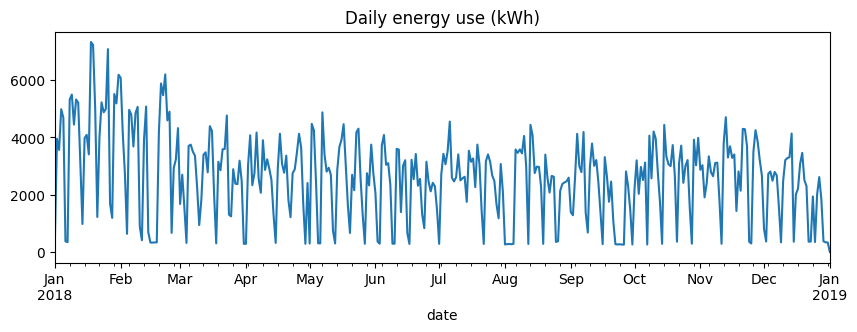

In [9]:
daily = steel.set_index("date")["Usage_kWh"].resample("D").sum()
daily.plot(title="Daily energy use (kWh)", figsize=(10, 3));

### Your turn 2.2
Change `"D"` (day) to `"W"` (week) to plot weekly totals.

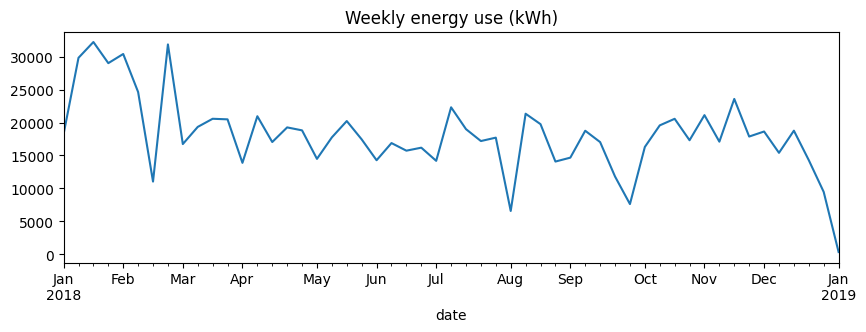

In [10]:
weekly = steel.set_index("date")["Usage_kWh"].resample("W").sum()
weekly.plot(title="Weekly energy use (kWh)", figsize=(10, 3));

## 4. Excel with title rows: the Kilbrack asset register

Load it the simple way first and look at the column names.

In [11]:
pd.read_excel("data/asset_register.xlsx").head(6)

,Kilbrack Engineering Ltd - Asset Register (FICTIONAL TRAINING DATA),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,Exported from CMMS on 30/09/2026 by maintenanc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Asset ID,Asset Description,Asset Type,Site,Install Date,Manufacturer,Rated Power,Criticality,Status
3,CNC-001,CNC Mill 1,CNC Mill,Galway,2018-06-19 00:00:00,Hartwell Machine Tools,38 kW,C,In Service
4,CNC-002,CNC Mill 2,CNC Mill,Cork Plant,2011-03-22 00:00:00,Hartwell Machine Tools,36kW,C,In Service
5,CNC-003,CNC Mill 3,CNC Mill,Limerick,22/06/2019,Hartwell Machine Tools,38000 W,A,In Service


The real header row (`Asset ID`, `Site`...) is the 4th row. Above it are a title, a note and a blank row.
`skiprows` tells pandas how many rows to skip.

### Your turn 2.3
How many rows should be skipped? Count the junk rows above the header in the output above.

In [12]:
register = pd.read_excel("data/asset_register.xlsx", skiprows=3)
register.head()

,Asset ID,Asset Description,Asset Type,Site,Install Date,Manufacturer,Rated Power,Criticality,Status
0,CNC-001,CNC Mill 1,CNC Mill,Galway,2018-06-19 00:00:00,Hartwell Machine Tools,38 kW,C,In Service
1,CNC-002,CNC Mill 2,CNC Mill,Cork Plant,2011-03-22 00:00:00,Hartwell Machine Tools,36kW,C,In Service
2,CNC-003,CNC Mill 3,CNC Mill,Limerick,22/06/2019,Hartwell Machine Tools,38000 W,A,In Service
3,CNC-004,CNC Mill 4,CNC Mill,Galway,2016-01-01,Hartwell Machine Tools,28.5,C,In Service
4,CNC-005,CNC Mill 5,CNC Mill,Limerick,08.06.2014,Hartwell Machine Tools,34.5 kW,B,In Service


In [13]:
check("Asset ID" in register.columns, "Header found.", "Expected a column called 'Asset ID'. Try a different number.")

PASS: Header found.


Excel files can have several sheets. This one has a second sheet called `Decommissioned`.

### Your turn 2.4
Load the second sheet by name.

In [14]:
decommissioned = pd.read_excel("data/asset_register.xlsx", sheet_name="Decommissioned")
decommissioned

,Asset ID,Asset Description,Asset Type,Site,Install Date,Manufacturer,Rated Power,Criticality,Status,Decommissioned On
0,CNC-015,CNC Mill (old),CNC Mill,Cork,2005-06-01,Hartwell Machine Tools,20 kW,C,Decommissioned,2025-06-30
1,CMP-009,Air Compressor (old),Air Compressor,Cork,2005-06-01,Nordvik Air,20 kW,C,Decommissioned,2025-06-30
2,CNV-011,Conveyor (old),Conveyor,Cork,2005-06-01,Linea Conveyors,20 kW,C,Decommissioned,2025-06-30
3,PMP-011,Pump (old),Pump,Cork,2005-06-01,Corrib Pumps,20 kW,C,Decommissioned,2025-06-30
4,HYP-009,Hydraulic Press (old),Hydraulic Press,Cork,2005-06-01,Dunmore Hydraulics,20 kW,C,Decommissioned,2025-06-30


## 5. The work orders, loaded properly

Two settings matter here:
* `na_values=["-"]`: this export uses `-` to mean "nothing". Blanks and `N/A` are treated as missing automatically.
* Dates: most are `dd/mm/yyyy HH:MM`, but a few were typed as `yyyy-mm-dd HH:MM`.

The helper below tries a list of formats in order, and tells you how many dates did not fit any of them.
Just run it.

In [15]:
# @title Helper: parse_dates(column, list_of_formats) (just run it)
def parse_dates(series, formats):
    result = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")
    for fmt in formats:
        result = result.fillna(pd.to_datetime(series, format=fmt, errors="coerce"))
    print(f"{result.isna().sum()} dates did not match any format")
    return result
print("parse_dates() is ready")

parse_dates() is ready


In [16]:
wo = pd.read_csv("data/work_orders_cmms.csv", na_values=["-"])

# Try with only the main format first
raised = parse_dates(wo["date_raised"], ["%d/%m/%Y %H:%M"])
wo.loc[raised.isna(), "date_raised"].head()

10 dates did not match any format


124    2025-08-21 15:45
132    2026-04-16 15:50
243    2025-10-12 17:15
397    2025-04-26 17:50
470    2026-02-25 17:30
Name: date_raised, dtype: object

### Your turn 2.5
Add the second format to the list: `%Y-%m-%d %H:%M` (year first, with dashes).

In [17]:
wo["date_raised"] = parse_dates(wo["date_raised"], ["%d/%m/%Y %H:%M", "%Y-%m-%d %H:%M"])

0 dates did not match any format


In [18]:
check(wo["date_raised"].isna().sum() == 0, "Every date parsed, and you know exactly which formats were in the file.",
      "Some dates still did not parse. Check the second format.")

PASS: Every date parsed, and you know exactly which formats were in the file.


Why not let pandas guess? Guessing is fine for a quick look. For something that runs every month you want it to
**tell you** when a new format appears, not make a silent guess.

## Optional extras

**Thermocouple data with a two-row header.** Run and look: the cooling curves of an aluminium alloy, from a sheet
with a title, a row of sensor positions, then the real header.

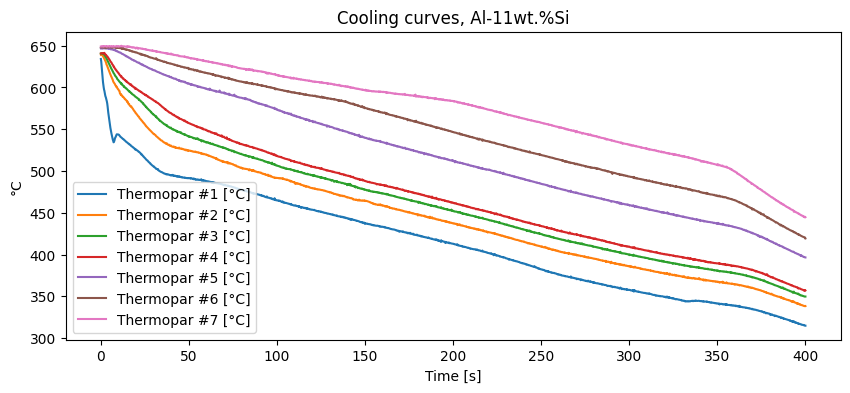

In [19]:
thermal = pd.read_excel("data/thermal-profiles.xlsx", sheet_name="Al-11wt.%Si", header=3)
thermal.set_index(thermal.columns[0]).plot(figsize=(10, 4), title="Cooling curves, Al-11wt.%Si", ylabel="°C");

**With Gemini:** `data/manifest.TXT` and `data/manifest.csv` both list the same microscopy files. Ask Gemini to help
you load the TXT into a table and compare the two. Do they agree? (Hint: count the files, and look at `TEMgrid06.TIF`.)

## Recap
* Tell `pd.to_datetime` the format. Day/month mix-ups give no error.
* Check time series go forwards.
* `skiprows` and `sheet_name` handle most Excel layouts.
* `na_values` adds extra "missing" markers.

Next: **03 Cleaning and Standardising**.